**Import Libraries**

In [3]:
!pip install tensorflow-federated
!pip install cryptography

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of tensorflow-federated to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.3/887.3 kB 57.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of tensorflow-federated to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance.

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from cryptography.fernet import Fernet
from google.colab import files

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


**EDA**

In [6]:
df = pd.read_csv("/content/gdrive/My Drive/heart_disease_dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,0.0,1.0,145.0,160.0,0.0,1.0,161.0,0.0,0.0,1.0,0.0,2.0,0.0
1,57.0,1.0,2.0,112.0,286.0,0.0,0.0,150.0,1.0,1.6,1.0,1.0,2.0,1.0
2,44.0,0.0,0.0,150.0,175.0,0.0,1.0,156.0,0.0,0.0,1.0,0.0,2.0,0.0
3,46.0,1.0,1.0,150.0,269.0,0.0,1.0,159.0,1.0,0.5,2.0,1.0,3.0,1.0
4,54.0,1.0,2.0,120.0,309.0,0.0,1.0,195.0,1.0,2.0,1.0,0.0,3.0,1.0


In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
df.shape

(3235, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3235 non-null   float64
 1   sex       3235 non-null   float64
 2   cp        3235 non-null   float64
 3   trestbps  3235 non-null   float64
 4   chol      3235 non-null   float64
 5   fbs       3235 non-null   float64
 6   restecg   3235 non-null   float64
 7   thalach   3235 non-null   float64
 8   exang     3235 non-null   float64
 9   oldpeak   3235 non-null   float64
 10  slope     3235 non-null   float64
 11  ca        3235 non-null   float64
 12  thal      3235 non-null   float64
 13  target    3235 non-null   float64
dtypes: float64(14)
memory usage: 354.0 KB


In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000,3235.000000
mean,54.533774,0.672302,0.937447,131.798502,246.302437,0.510055,0.522574,149.116613,0.440622,1.046243,1.395919,0.742440,2.298034,0.540649
std,8.976545,0.469404,1.026009,18.004546,52.531289,0.499919,0.521011,23.212151,0.496853,1.168006,0.611208,1.023453,0.607317,0.498422
min,28.661793,-0.024556,-0.071508,93.304637,123.758968,-0.028420,-0.033105,69.617540,-0.031838,-0.074034,-0.029055,-0.087065,-0.011382,0.000000
25%,47.829891,0.006625,0.000000,119.998705,210.473903,0.000000,0.000000,132.783423,-0.000396,0.012786,0.997654,-0.001424,1.994640,0.000000
50%,55.868154,0.994835,0.973762,129.982563,240.879546,0.980413,0.979625,152.337157,0.012315,0.776862,1.015948,0.022733,2.007764,1.000000
75%,61.015992,1.002110,1.995305,140.141569,275.048038,1.000000,1.000000,165.798135,0.999695,1.772279,1.999247,1.016615,2.995372,1.000000
max,77.252090,1.032402,3.069119,200.544513,565.208396,1.032028,2.023007,202.707794,1.028932,6.228175,2.036469,4.038031,3.038514,1.000000


/tmp/ipykernel_1016/715622588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=df, palette='PuBuGn')


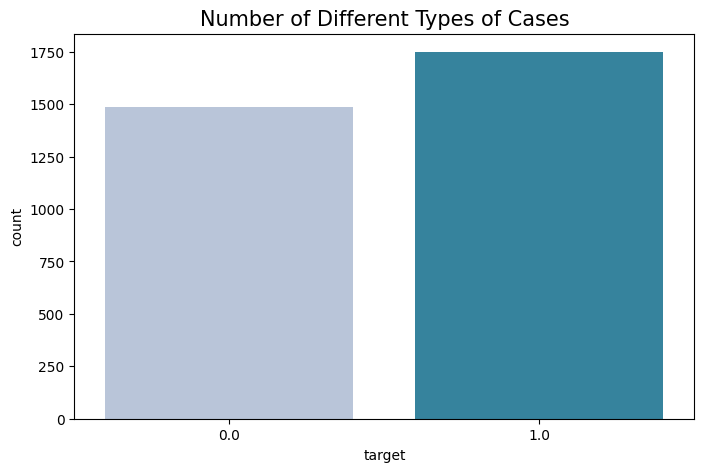

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='target',data=df, palette='PuBuGn')
plt.title('Number of Different Types of Cases', fontsize=15)
plt.show()

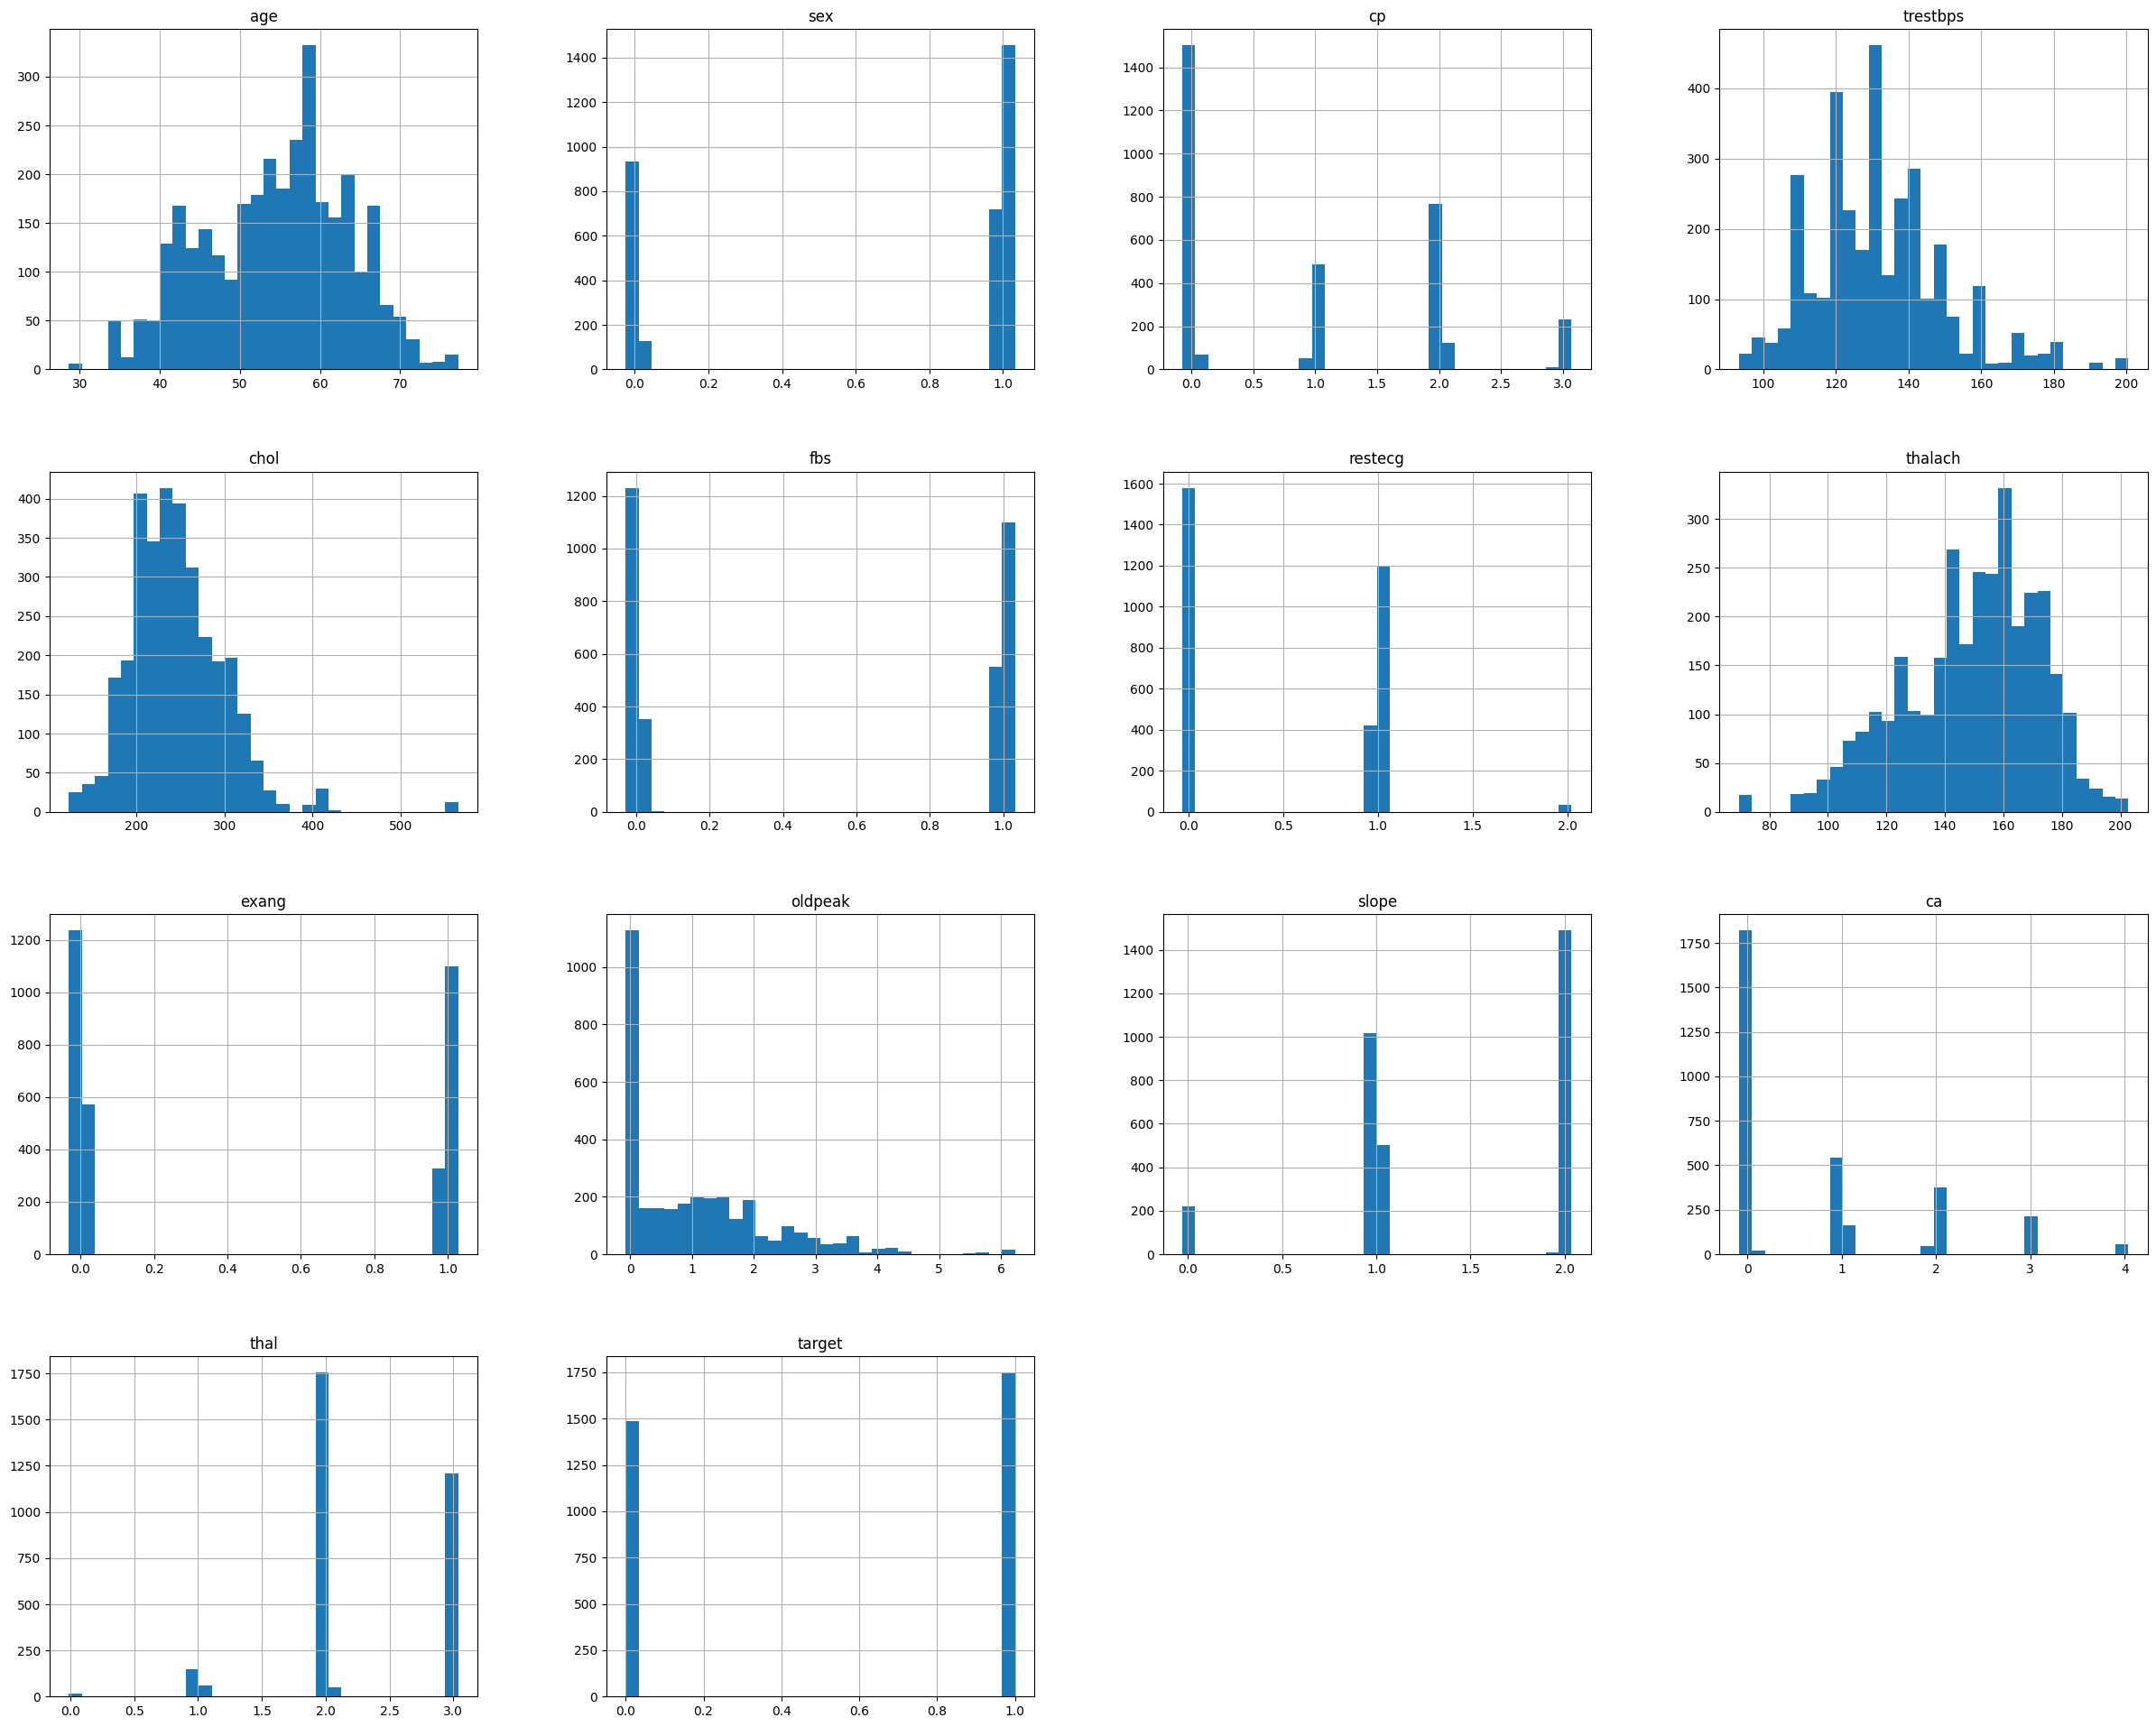

In [12]:
df.hist(figsize=(30,24),bins = 30)
plt.title("Features Distribution")
plt.show()

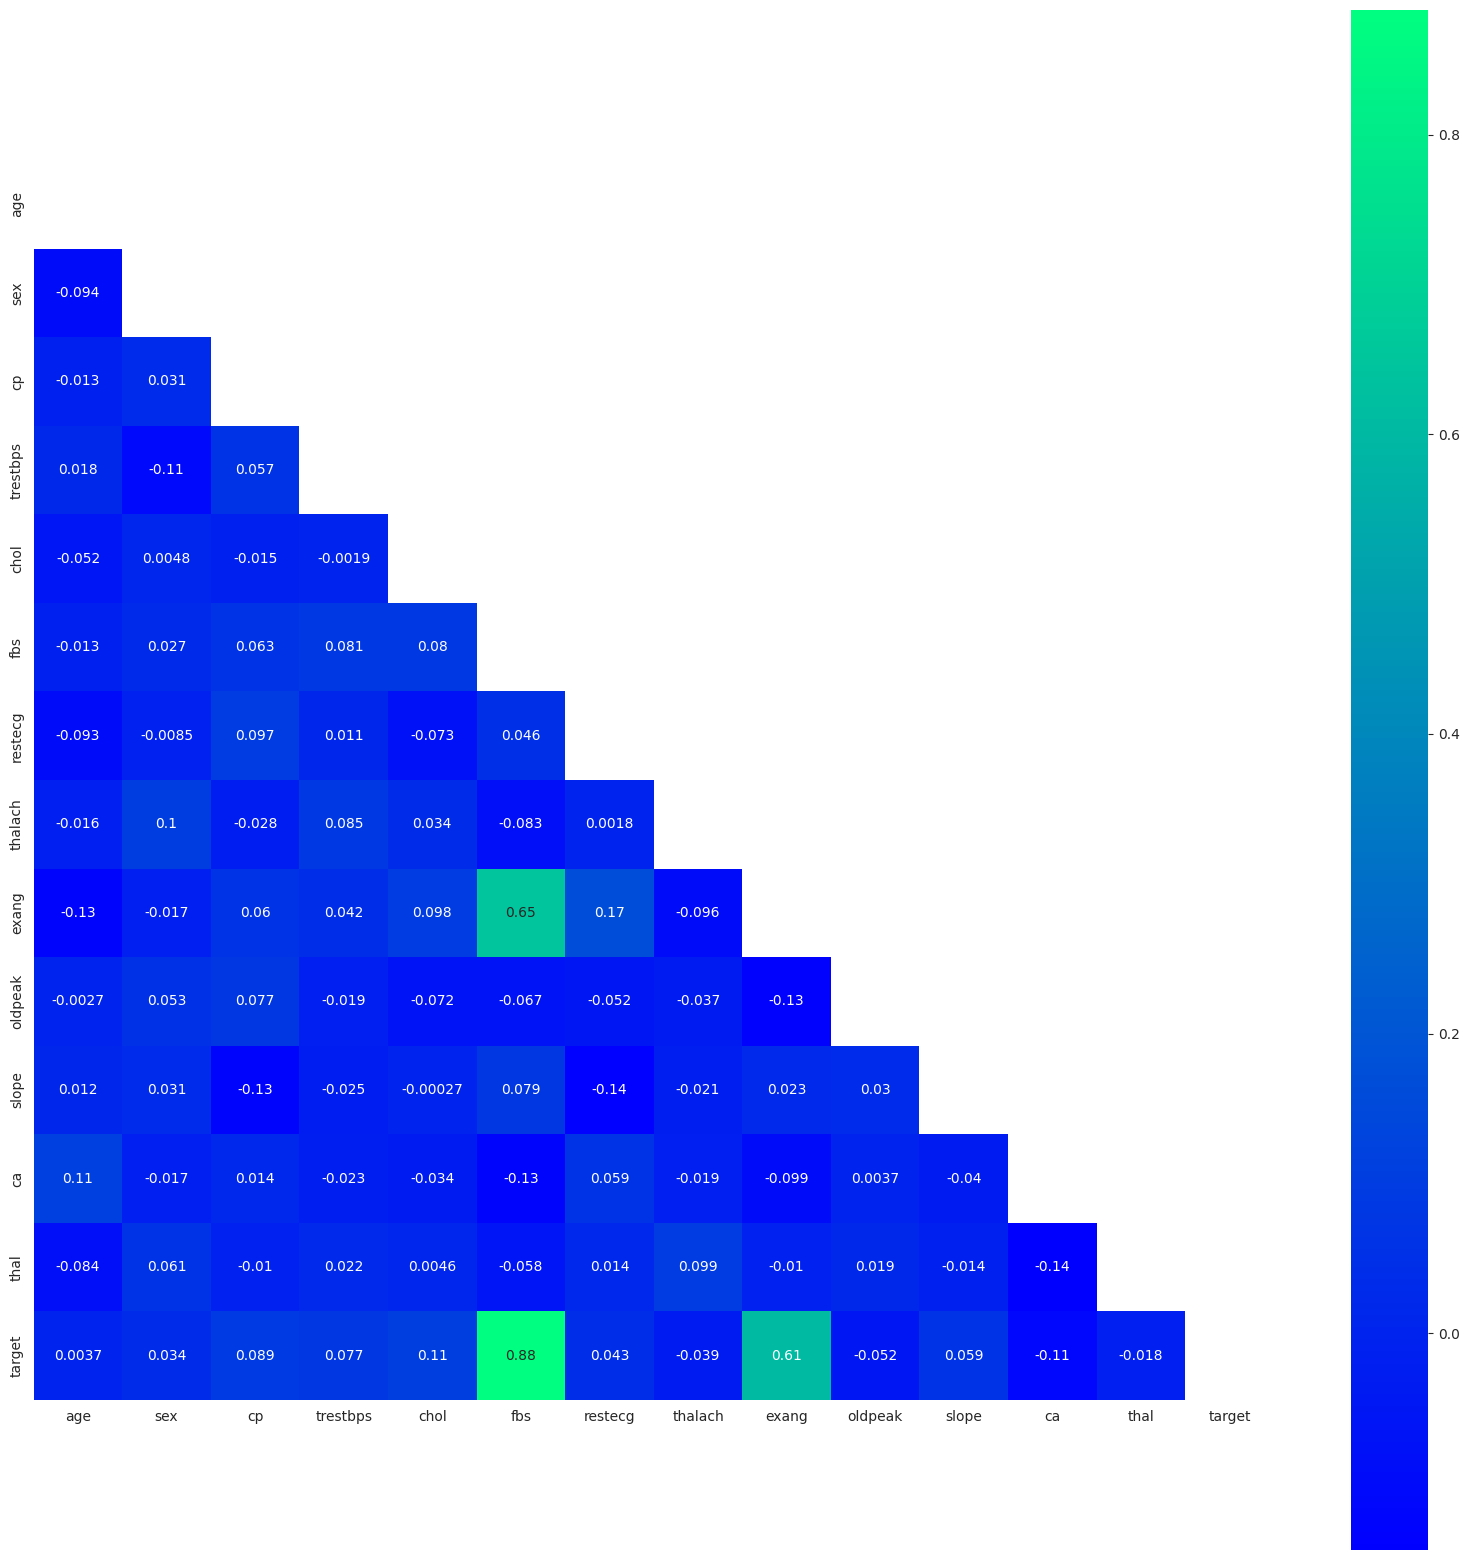

In [13]:
plt.figure(figsize=(20,20))
corr=df.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask,square=True, annot=True, cmap='winter')

**Data Splitting**

In [14]:
X = df.drop("target", axis=1).values
y = df["target"].values

# First split the raw data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)

# Transform the test data using the training-fitted scaler
X_test = scaler.transform(X_test_raw)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2588, 13)
Test set shape: (647, 13)


In [15]:
def create_client_data(X, y, num_clients=3):
    client_data = []
    split_size = len(X) // num_clients
    for i in range(num_clients):
        start = i * split_size
        end = (i+1) * split_size
        client_data.append((X[start:end], y[start:end]))
    return client_data

clients = create_client_data(X_train, y_train, num_clients=3)


# Multi-Scale CNN + Graph Layer + Graph Attention

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, Concatenate, Conv1D, BatchNormalization,
    GlobalAveragePooling1D, Dropout, Reshape, Input
)
from tensorflow.keras.models import Model


# =====================================================
# Graph Layer
# =====================================================
class GraphLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.proj = Dense(
            self.units,
            activation='relu'
        )

    def call(self, x):

        # Graph similarity matrix
        A = tf.matmul(
            x,
            x,
            transpose_b=True
        )

        # Normalize graph connections
        A = tf.nn.softmax(
            A,
            axis=-1
        )

        # Graph feature propagation
        out = tf.matmul(
            A,
            x
        )

        return self.proj(out)


#  Graph Attention Layer

class GraphAttentionLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.W = Dense(
            self.units
        )

    def call(self, x):

        # Project node features
        h = self.W(x)

        # Attention similarity
        scores = tf.matmul(
            h,
            h,
            transpose_b=True
        )

        # Attention coefficients
        scores = tf.nn.softmax(
            scores,
            axis=-1
        )

        # Attention-based feature aggregation
        out = tf.matmul(
            scores,
            h
        )

        return out


#  MULTI-SCALE CNN + GRAPH + GRAPH ATTENTION

def create_model():

    inputs = Input(
        shape=(X_train.shape[1],)
    )


    # Multi-Scale CNN


    x = Reshape(
        (X_train.shape[1], 1)
    )(inputs)

    conv3 = Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(x)

    conv5 = Conv1D(
        32,
        5,
        padding='same',
        activation='relu'
    )(x)

    # Multi-scale feature fusion
    x = Concatenate()([
        conv3,
        conv5
    ])

    x = BatchNormalization()(x)


    # Graph Layer


    graph_features = GraphLayer(
        64
    )(x)


    # Graph Attention


    attention_features = GraphAttentionLayer(
        64
    )(x)



    # Graph + Graph Attention Fusion


    fusion = Concatenate()([
        graph_features,
        attention_features
    ])



    # Global Pooling


    fusion = GlobalAveragePooling1D()(
        fusion
    )



    # Classification


    fusion = Dense(
        128,
        activation='relu'
    )(fusion)

    outputs = Dense(
        1,
        activation='sigmoid'
    )(fusion)



    # Model


    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy'
        ]
    )

    return model

In [17]:
import pickle

def federated_training(clients, local_epochs=5):
    global_model = create_model()
    client_models = []   # store trained client models
    client_histories = [] # Added back client_histories

    # Encryption setup
    key = Fernet.generate_key()
    cipher = Fernet(key)
    encrypted_weights = []

    # Train clients
    for idx, (Xc, yc) in enumerate(clients):
        client_model = create_model()
        client_model.set_weights(global_model.get_weights())

        history = client_model.fit(Xc, yc, epochs=local_epochs, batch_size=8, verbose=1, validation_split=0.2)
        client_histories.append(history.history) # Append history

        # Evaluate client model
        loss_c, acc_c = client_model.evaluate(X_test, y_test, verbose=0)
        #print(f"   Client {idx+1} -> Loss: {loss_c:.4f}, Accuracy: {acc_c:.4f}")

        client_models.append(client_model)

        # Encrypt weights
        # Serialize weights using pickle before encryption
        weights_bytes = pickle.dumps(client_model.get_weights())
        enc = cipher.encrypt(weights_bytes)
        encrypted_weights.append(enc)

    # Decrypt & aggregate for global model
    decrypted_weights = []
    for enc in encrypted_weights:
        dec = cipher.decrypt(enc)
        # Deserialize weights using pickle after decryption
        weights = pickle.loads(dec)
        decrypted_weights.append(weights)

    # Aggregate weights
    aggregated_weights = []
    for i in range(len(decrypted_weights[0])):
        layer_weights = np.array([client_weights[i] for client_weights in decrypted_weights])
        aggregated_weights.append(np.mean(layer_weights, axis=0))

    global_model.set_weights(aggregated_weights)

    # Evaluate global model
    loss, acc = global_model.evaluate(X_test, y_test, verbose=1)
    return global_model, client_models, client_histories # Added back client_histories

In [ ]:
global_model, client_models, client_histories = federated_training(clients, local_epochs=500)

Epoch 1/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5791 - loss: 0.6719 - val_accuracy: 0.6647 - val_loss: 0.6731
Epoch 2/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6981 - loss: 0.6283 - val_accuracy: 0.6994 - val_loss: 0.6454
Epoch 3/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6952 - loss: 0.6021 - val_accuracy: 0.6879 - val_loss: 0.6129
Epoch 4/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6996 - loss: 0.5827 - val_accuracy: 0.6879 - val_loss: 0.5871
Epoch 5/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6981 - loss: 0.5853 - val_accuracy: 0.6936 - val_loss: 0.5734
Epoch 6/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.5845 - val_accuracy: 0.6994 - val_loss: 0.5680
Epoch 7/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7097 - loss: 0.5866 - val_accuracy: 0.7052 - val_loss: 0.5657
Epoch 8/500
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7112 - loss: 0.5640 - val_accuracy: 0.6994 -

In [19]:
global_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 13, 1)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 32)    │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 13, 32)    │        192 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 13, 64)    │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 13, 64)    │        256 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_layer         │ (None, 13, 64)    │      4,160 │ batch_normalizat… │
│ (GraphLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_attention_la… │ (None, 13, 64)    │      4,160 │ batch_normalizat… │
│ (GraphAttentionLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 13, 128)   │          0 │ graph_layer[0][0… │
│ (Concatenate)       │                   │            │ graph_attention_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,537 (99.75 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 128 (512.00 B)

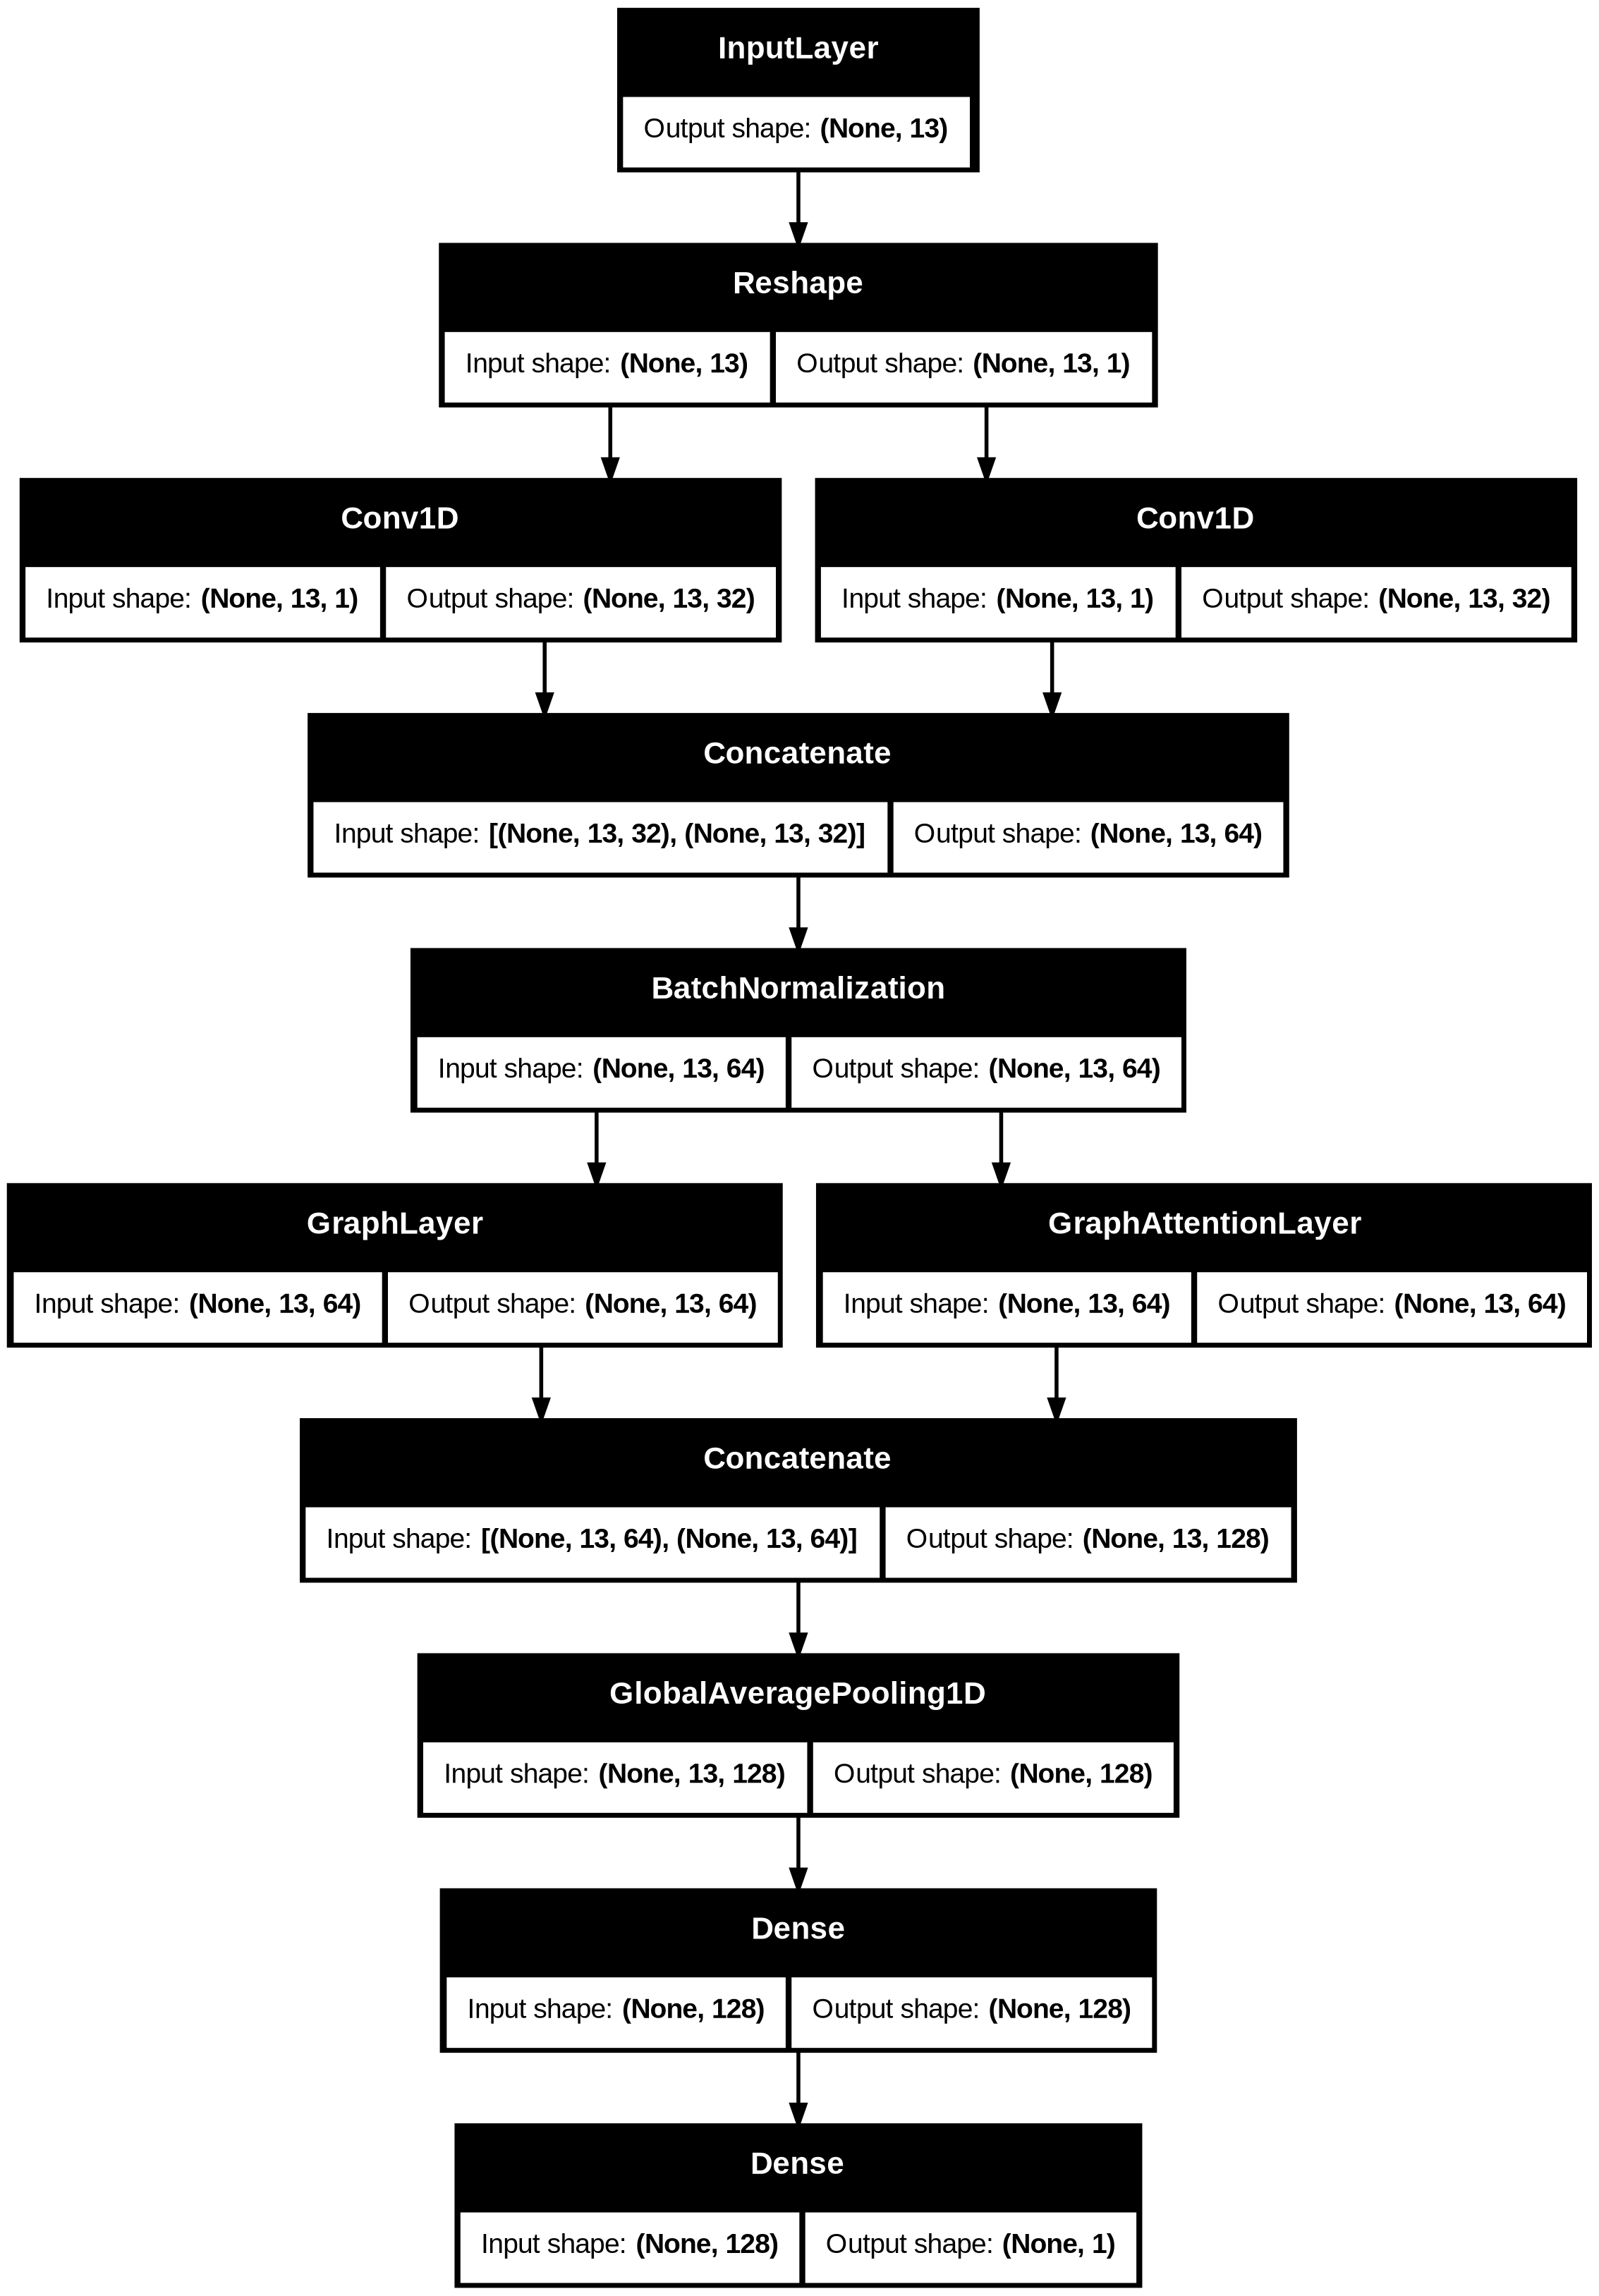

In [20]:
from tensorflow.keras.utils import plot_model
plot_model(global_model, to_file='model.png', show_shapes=True)

**Model Evaluation**

In [32]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, name="Model"):


    # PREDICTIONS

    y_pred_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)



    # CONFUSION MATRIX


    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)



    # OVERALL MODEL PERFORMANCE

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    print("\n===== Overall Model Performance =====")
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"F1-score : {f1 * 100:.2f}%")



    # CONFUSION MATRIX PLOT

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Multi-Scale CNN + Graph Layer + Graph Attention Confusion Matrix")

    plt.tight_layout()
    plt.show()



    # ROC CURVE

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_pred_prob
    )

    roc_auc = auc(fpr, tpr)


    plt.figure(figsize=(6, 4))

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-Scale CNN + Graph Layer + Graph Attention ROC Curve")

    plt.legend()

    plt.tight_layout()
    plt.show()

Confusion Matrix:
[[266  31]
 [ 20 330]]

===== Overall Model Performance =====
Accuracy : 92.12%
Precision: 92.21%
Recall   : 91.92%
F1-score : 92.04%


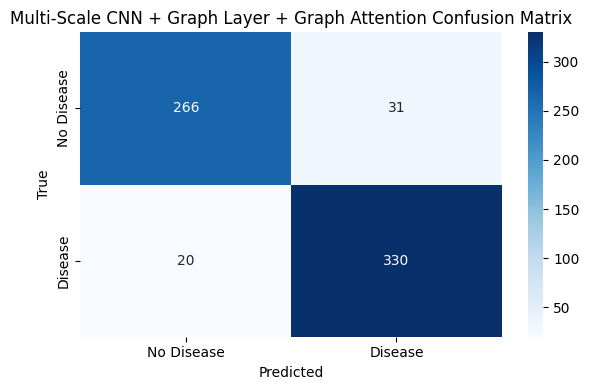

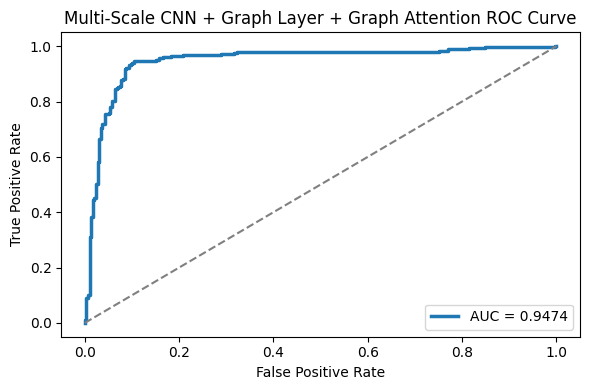

In [ ]:

# Global
evaluate_model(global_model, name="Global Model")
